#Intro and problem facing

**Briefly summarize your business problem, explain why it matters, and state your conclusion.**

It is our job to predict the sales price for each house. For each Id in the test set, we must predict the value of the SalePrice variable.

## In Our Analysis, We Will:
- Explore the data thoroughly before modeling.
- Engineer meaningful features and consider introducing non-linearities.
- Think carefully about whether to transform the data.
- Compare multiple models and evaluate their performance (e.g., LASSO vs. your selected model).
- Present results clearly and justify your modeling choices.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

##Data
Explain what data you use and why it is relevant to the problem. Describe any steps you took in your
code related to data handling, such as exploratory data analysis (EDA), cleaning, or feature
engineering

Loading the data

In [ ]:
# Install Kaggle library
!pip install kaggle

# prep for uploading kaggle.json
from google.colab import files
print('Upload your Kaggle API key to this virtual environment.')
files.upload()

# create the directories to store the JSON file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip house-prices-advanced-regression-techniques.zip

Upload your Kaggle API key to this virtual environment.


Saving kaggle.json to kaggle.json
  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 706MB/s]
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
# Load test.csv to test df and train.csv to train df
df_test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')

Getting to know the data through data exploration

In [ ]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# look at shape of the data
df_train.shape

(1460, 81)

In [ ]:
# Look for null values and information about the dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Temporarily combine training and testing sets for preprocessing so they have the same columns after categorical encoding
test_ids = df_test['Id']

y = df_train['SalePrice']
df_train = df_train.drop('SalePrice', axis=1)

combined_df = pd.concat([df_train, df_test], axis=0)

# drop id from both datasets
combined_df = combined_df.drop('Id', axis=1)

In [ ]:
# List categorical columns

categorical_cols = combined_df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
# Describing Numerical Columns
combined_df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,...,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,...,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737
std,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,...,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,...,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,...,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,...,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,...,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [ ]:
# Drop columns with many null values
combined_df=combined_df.drop(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC','Fence','MiscFeature'], axis='columns')

# fill missing data with 0, column mode, or mean to avoid losing many records with a broad dropna. We need to do this and dummy encoding to the test and train datasets at the same time, otherwise they will have different columns

# mode for catagorical fields
for col in ('MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond',
            'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'KitchenQual',
            'Functional', 'GarageCars', 'SaleType'):
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

# 0 for fields that have mode 0 or are integers with missing values
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'TotalBsmtSF',
            'MasVnrArea', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond'):
    combined_df[col] = combined_df[col].fillna(0)

# mean for contiunous numeric fields
for col in ('BsmtUnfSF', 'GarageArea', 'LotFrontage'):
    combined_df[col] = combined_df[col].fillna(combined_df[col].mean())

In [ ]:
# Get dummy variables
objects = []
for c in combined_df.columns:
    if str(combined_df[c].dtype) == 'object':
        objects.append(c)
X_ = combined_df.drop(objects, axis = 1).astype('float64')

dummies = pd.get_dummies(combined_df[objects], drop_first=True)
combined_df_processed = pd.concat([X_, dummies], axis = 1)

In [ ]:
# Once testing and training data has been preprocessed, split them back apart

X = combined_df_processed.iloc[:len(df_train)]
test_data_processed = combined_df_processed.iloc[len(df_train):]

In [ ]:
# Scale training data

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Scale test data on the same scale that was used for training data, but do not refit
test_data_scaled = scaler.transform(test_data_processed)

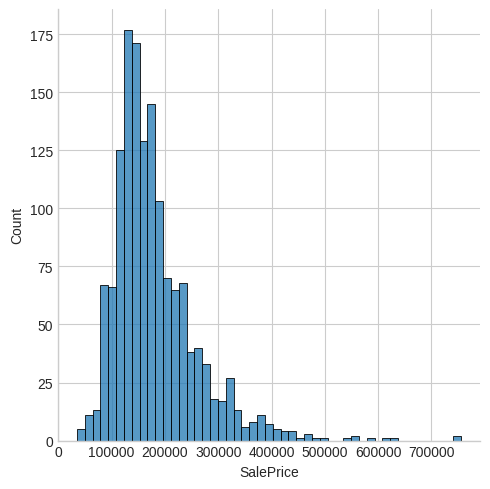

In [ ]:
# y is right skewed

sns.displot(y);

In [ ]:
# Since the distribution of y is right skewed, take its log
y_log = np.log1p(y)

# Train/test split the training set for model building
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
y_log_train = np.log1p(y_train)

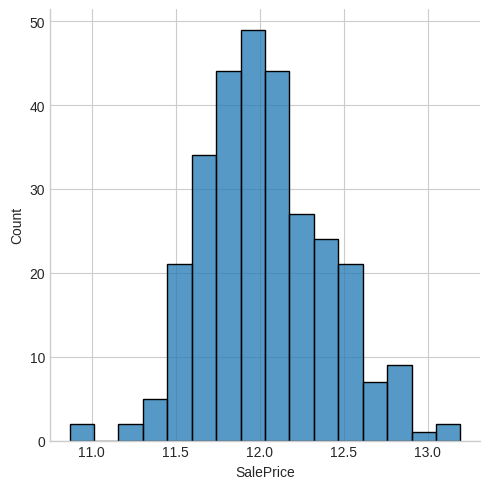

In [ ]:
# Distribution of y_log is more normal
sns.displot(y_log_train);

##Model
Describe the models you apply. You should compare at least two models:
• One benchmark model (e.g., linear regression, baseline classifier)
• One proposed model that you believe will perform better
Briefly explain why you chose each model and how they differ

### Benchmark OLS model
This simple model will include all features and serve as a baseline for comparison with more advanced models and feature selection.

In [ ]:
ols = LinearRegression()

ols.fit(X_train, y_log_train)

# Calculate the negative mean squared error
scores = cross_val_score(ols, X, y, cv=5, scoring='neg_mean_squared_error')

# Result is the Root Mean Squared Error (RMSE)
rmse_scores = np.sqrt(-scores)

print(f"RMSE scores for each of the 5 folds: {rmse_scores}")
print(f"Average RMSE across all folds: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")

RMSE scores for each of the 5 folds: [68949.2267106  33843.9625754  37389.70277955 24064.76878
 45692.25968364]
Average RMSE across all folds: 41987.9841
Standard deviation of RMSE: 15161.4062


In [ ]:
# Make predictions using the test portion of the data

test_ols = np.expm1(ols.predict(test_data_scaled))
test_ols

array([139088.99117372, 268689.2546777 , 187900.03018564, ...,
       180029.5760796 , 121368.31597785, 212161.64372985])

### LASSO imporved model
Since we have a large number of features in this dataset, we will use a LASSO model to select relevant ones and build an effective model that avoids overfitting.

In [ ]:
# Initialize the LassoCV model
lasso_cv = LassoCV(n_alphas=200, cv=5, random_state=42, n_jobs=-1, max_iter=10000)

# Fit the model
lasso_cv.fit(X, y_log)

# Display the best alpha found
best_alpha = lasso_cv.alpha_
print(f"Best alpha (λ) found via cross-validation: {best_alpha:.6f}")

Best alpha (λ) found via cross-validation: 0.004258


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-258178864.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Alpha ($\lambda$)')


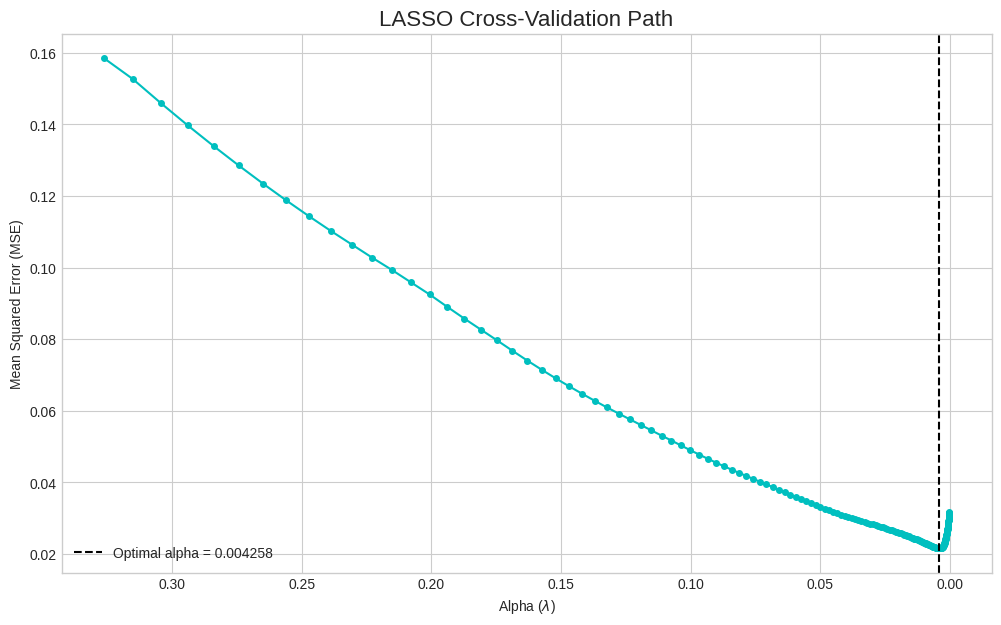

LassoCV Model Test Set RMSE: 29995.8329

Total features available: 232
Features selected by LASSO (coefficients != 0): 87


In [ ]:
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)

# Plot the relationship between Alpha and MSE
plt.figure(figsize=(12, 7))
plt.plot(lasso_cv.alphas_, mean_mse_path, marker='o', linestyle='-', markersize=4, color='c')
# Plot a vertical line at the location of the best alpha
plt.axvline(lasso_cv.alpha_, linestyle='--', color='k',
            label=f'Optimal alpha = {lasso_cv.alpha_:.6f}')
plt.legend()
plt.xlabel('Alpha ($\lambda$)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('LASSO Cross-Validation Path', fontsize=16)

# The alphas are tested from largest to smallest, so we reverse the x-axis for intuitive plotting
plt.gca().invert_xaxis()
plt.show()

# Make predictions on the test set using the tuned LASSO model
y_log_pred_lasso_cv = lasso_cv.predict(X_test)
y_pred_lasso_cv = np.expm1(y_log_pred_lasso_cv)

# Calculate and print the RMSE
rmse_lasso_cv = np.sqrt(mean_squared_error(y_test, y_pred_lasso_cv))
print(f"LassoCV Model Test Set RMSE: {rmse_lasso_cv:.4f}")

# Analyze the number of selected features
n_total_features = X_train.shape[1] - 1 # excluding the constant term
n_selected_features = np.sum(lasso_cv.coef_[1:] != 0)
print(f"\nTotal features available: {n_total_features}")
print(f"Features selected by LASSO (coefficients != 0): {n_selected_features}")

In [ ]:
# Create a DataFrame to store features and their coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': combined_df_processed.columns,
    'Coefficient': lasso_cv.coef_
})

# Filter out features with a coefficient of 0 (features not selected by LASSO)
selected_features = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]

# Sort the selected features by the absolute value of their coefficient to see the most impactful ones
most_impactful_features = selected_features.reindex(selected_features['Coefficient'].abs().sort_values(ascending=False).index)

print("Features selected by LASSO and their coefficients (sorted by absolute value):")
display(most_impactful_features)

Features selected by LASSO and their coefficients (sorted by absolute value):


,Feature,Coefficient
15,GrLivArea,0.102903
3,OverallQual,0.095267
25,GarageCars,0.040973
5,YearBuilt,0.036107
4,OverallCond,0.035368
...,...,...
208,GarageQual_Ex,0.000549
30,3SsnPorch,0.000303
47,Utilities_NoSeWa,-0.000257
134,Exterior2nd_CmentBd,0.000235


/tmp/ipython-input-3353330357.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_positive_features, palette='viridis') # Changed data to top_positive_features


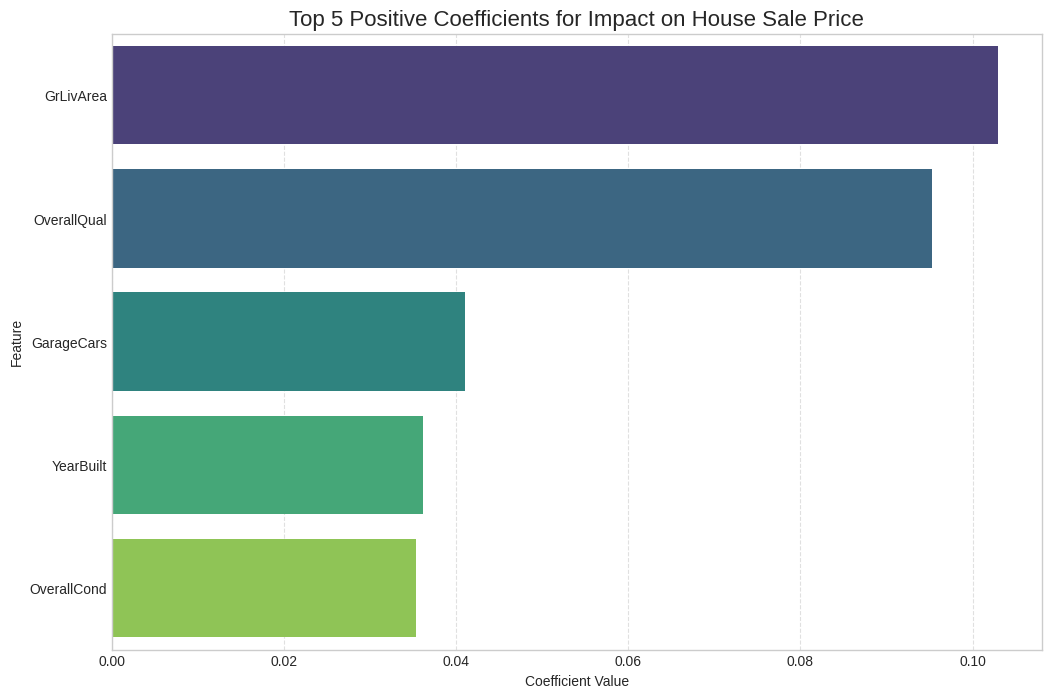

In [ ]:
# Sort by absolute coefficient for better visualization
most_impactful_features_sorted = most_impactful_features.sort_values(by='Coefficient', ascending=False)

# Select the top 5 most positive and top 5 most negative features
top_positive_features = most_impactful_features_sorted.head(5)
top_negative_features = most_impactful_features_sorted.tail(5)


plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_positive_features, palette='viridis') # Changed data to top_positive_features
plt.title('Top 5 Positive Coefficients for Impact on House Sale Price', fontsize=16) # Updated title
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Make predictions on test data using the LASSO model

y_pred_lasso = np.expm1(lasso_cv.predict(test_data_scaled))
y_pred_lasso

array([112749.30729678, 148565.11273049, 173673.49112096, ...,
       161850.81308279, 116865.10419174, 231415.87171344])

##Results
Define the performance metrics you use to evaluate the models (e.g., MSE, accuracy, precision,
recall). Compare the results of your models (e.g., LASSO vs. your selected model).
Use tables and/or figures to illustrate key findings where appropriate.


In [ ]:
# Make predictions on the test split of the training data using the OLS model
y_log_pred_ols = ols.predict(X_test)
y_pred_ols = np.expm1(y_log_pred_ols)

# Calculate and print the RMSE for the OLS model
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

# Calculate R2 for each model using the log-transformed target variable
r2_ols = ols.score(X_test, np.log1p(y_test))
r2_lasso_cv = lasso_cv.score(X_test, np.log1p(y_test))

results_table = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'OLS Model': [rmse_ols, r2_ols],
    'LassoCV Model': [rmse_lasso_cv, r2_lasso_cv]
})

print("Model evaluation with testing data")
display(results_table)

Model evaluation with testing data


,Metric,OLS Model,LassoCV Model
0,RMSE,80874.879790,29995.832878
1,R2 Score,0.673081,0.905634


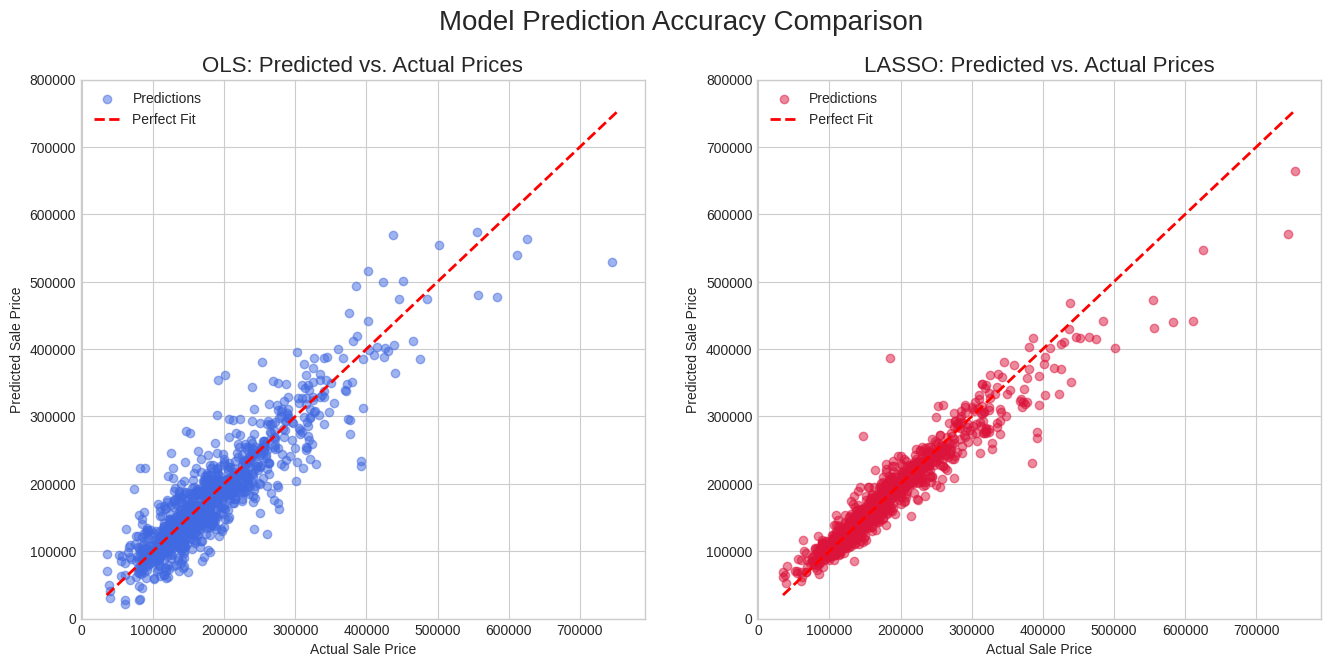

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# OLS
axes[0].scatter(y_test, y_pred_ols, alpha=0.5, color='royalblue', label='Predictions')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red', label='Perfect Fit')
axes[0].set_xlabel("Actual Sale Price")
axes[0].set_ylabel("Predicted Sale Price")
axes[0].set_title("OLS: Predicted vs. Actual Prices", fontsize=16)
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim(0, 800000)

# LASSO
axes[1].scatter(y_test, y_pred_lasso_cv, alpha=0.5, color='crimson', label='Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red', label='Perfect Fit')
axes[1].set_xlabel("Actual Sale Price")
axes[1].set_ylabel("Predicted Sale Price")
axes[1].set_title("LASSO: Predicted vs. Actual Prices", fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 800000)

plt.suptitle('Model Prediction Accuracy Comparison', fontsize=20)
plt.show()


## Results

Comparing the baseline OLS model with the LASSO model, we can see that LASSO outperforms OLS with a higher R2 and lower RSME.

This can be seen in the graphs where the predictions from the OLS model are grouped more tightly around the perfect fit line.

This is due to LASSO's feature selection since it was able to remove noise from the model and use a subset of features that are most relevant to the outcome instead of including all of them like OLS.